# Imports

This is a notebook forked on Kaggle from Fantine Huot. Most of the data opening is from her work. In order to improve the model precision, I cleaned the initial data set by automatically removing several data points (where the model tried to make a guess but with no input...ie with no heatspot corresponding to a wildfire in the frame). Removing them slows down the notebook given that the initial data set is stored as TFRecords. These are the modifications I made to the initial code. Then I added cells below.

Everything arround the model is mine and the second part of the visualization too. 

With a friend, we are working on improving this work by creating a whole new dataset (with a lower time-step of just 1h instead of 24h). On this new dataset, we are using a ConvLSTM to predict wildfire propagation several hours ahead given physical parameters and weather predictions. This suppose getting arround the uneven timing of satellites infrared pictures (lots of missing data).

This notebook was a first test to better grasp the problem, understand what were the limitations and what could or could not work. 


I have added a cell with ****DHD**** from the point on where everything is my work.



Import the required libraries.

In [1]:
import re
from typing import Dict, List, Optional, Text, Tuple
import matplotlib.pyplot as plt
from matplotlib import colors

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras

from keras.models import load_model

# Load the dataset

Enter the Unix glob file pattern of the data files.

Here we load the training data. All the data are stored in TensorFlow Record files.
Replace 'train' with 'eval' or 'test' to load the evaluation or testing data, respectively.

In [2]:
file_pattern = '/kaggle/input/next-day-wildfire-spread/next_day_wildfire_spread_train*'

Run the following three cells to define the required library functions for loading the data.

The first cell defines the name of the variables in the input files and the corrresponding data statistics. The statistics can be used for preprocessing the data. 

In [3]:
"""Constants for the data reader."""

INPUT_FEATURES = ['elevation', 'th', 'vs',  'tmmn', 'tmmx', 'sph', 
                  'pr', 'pdsi', 'NDVI', 'population', 'erc', 'PrevFireMask']

OUTPUT_FEATURES = ['FireMask', ]

# Data statistics 
# For each variable, the statistics are ordered in the form:
# (min_clip, max_clip, mean, standard deviation)
DATA_STATS = {
    # Elevation in m.
    # 0.1 percentile, 99.9 percentile
    'elevation': (0.0, 3141.0, 657.3003, 649.0147),
    # Pressure
    # 0.1 percentile, 99.9 percentile
    'pdsi': (-6.12974870967865, 7.876040384292651, -0.0052714925, 2.6823447),
    'NDVI': (-9821.0, 9996.0, 5157.625, 2466.6677),  # min, max
    # Precipitation in mm.
    # Negative values do not make sense, so min is set to 0.
    # 0., 99.9 percentile
    'pr': (0.0, 44.53038024902344, 1.7398051, 4.482833),
    # Specific humidity.
    # Negative values do not make sense, so min is set to 0.
    # The range of specific humidity is up to 100% so max is 1.
    'sph': (0., 1., 0.0071658953, 0.0042835088),
    # Wind direction in degrees clockwise from north.
    # Thus min set to 0 and max set to 360.
    'th': (0., 360.0, 190.32976, 72.59854),
    # Min/max temperature in Kelvin.
    # -20 degree C, 99.9 percentile
    'tmmn': (253.15, 298.94891357421875, 281.08768, 8.982386),
    # -20 degree C, 99.9 percentile
    'tmmx': (253.15, 315.09228515625, 295.17383, 9.815496),
    # Wind speed in m/s.
    # Negative values do not make sense, given there is a wind direction.
    # 0., 99.9 percentile
    'vs': (0.0, 10.024310074806237, 3.8500874, 1.4109988),
    # NFDRS fire danger index energy release component expressed in BTU's per
    # square foot.
    # Negative values do not make sense. Thus min set to zero.
    # 0., 99.9 percentile
    'erc': (0.0, 106.24891662597656, 37.326267, 20.846027),
    # Population density
    # min, 99.9 percentile
    'population': (0., 2534.06298828125, 25.531384, 154.72331),
    # We don't want to normalize the FireMasks.
    # 1 indicates fire, 0 no fire, -1 unlabeled data
    'PrevFireMask': (-1., 1., 0., 1.),
    'FireMask': (-1., 1., 0., 1.)
}

The following cell defines cropping functions for extracting regions of the desired size from the input data.

In [4]:
"""Library of common functions used in deep learning neural networks.
"""
def random_crop_input_and_output_images(
    input_img: tf.Tensor,
    output_img: tf.Tensor,
    sample_size: int,
    num_in_channels: int,
    num_out_channels: int,
) -> Tuple[tf.Tensor, tf.Tensor]:
  """Randomly axis-align crop input and output image tensors.

  Args:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
    sample_size: side length (square) to crop to.
    num_in_channels: number of channels in input_img.
    num_out_channels: number of channels in output_img.
  Returns:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
  """
  combined = tf.concat([input_img, output_img], axis=2)
  combined = tf.image.random_crop(
      combined,
      [sample_size, sample_size, num_in_channels + num_out_channels])
  input_img = combined[:, :, 0:num_in_channels]
  output_img = combined[:, :, -num_out_channels:]
  return input_img, output_img


def center_crop_input_and_output_images(
    input_img: tf.Tensor,
    output_img: tf.Tensor,
    sample_size: int,
) -> Tuple[tf.Tensor, tf.Tensor]:
  """Center crops input and output image tensors.

  Args:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
    sample_size: side length (square) to crop to.
  Returns:
    input_img: tensor with dimensions HWC.
    output_img: tensor with dimensions HWC.
  """
  central_fraction = sample_size / input_img.shape[0]
  input_img = tf.image.central_crop(input_img, central_fraction)
  output_img = tf.image.central_crop(output_img, central_fraction)
  return input_img, output_img

The following cell provides code for parsing the contents of the TensorFlow Record files. In addition to loading the data, it also offers functions for various preprocessing operations, such as clipping, rescaling, or normalizing the data.  

In [5]:
"""Dataset reader for Earth Engine data."""

def _get_base_key(key: Text) -> Text:
  """Extracts the base key from the provided key.

  Earth Engine exports TFRecords containing each data variable with its
  corresponding variable name. In the case of time sequences, the name of the
  data variable is of the form 'variable_1', 'variable_2', ..., 'variable_n',
  where 'variable' is the name of the variable, and n the number of elements
  in the time sequence. Extracting the base key ensures that each step of the
  time sequence goes through the same normalization steps.
  The base key obeys the following naming pattern: '([a-zA-Z]+)'
  For instance, for an input key 'variable_1', this function returns 'variable'.
  For an input key 'variable', this function simply returns 'variable'.

  Args:
    key: Input key.

  Returns:
    The corresponding base key.

  Raises:
    ValueError when `key` does not match the expected pattern.
  """
  match = re.match(r'([a-zA-Z]+)', key)
  if match:
    return match.group(1)
  raise ValueError(
      'The provided key does not match the expected pattern: {}'.format(key))


def _clip_and_rescale(inputs: tf.Tensor, key: Text) -> tf.Tensor:
  """Clips and rescales inputs with the stats corresponding to `key`.

  Args:
    inputs: Inputs to clip and rescale.
    key: Key describing the inputs.

  Returns:
    Clipped and rescaled input.

  Raises:
    ValueError if there are no data statistics available for `key`.
  """
  base_key = _get_base_key(key)
  if base_key not in DATA_STATS:
    raise ValueError(
        'No data statistics available for the requested key: {}.'.format(key))
  min_val, max_val, _, _ = DATA_STATS[base_key]
  inputs = tf.clip_by_value(inputs, min_val, max_val)
  return tf.math.divide_no_nan((inputs - min_val), (max_val - min_val))


def _clip_and_normalize(inputs: tf.Tensor, key: Text) -> tf.Tensor:
  """Clips and normalizes inputs with the stats corresponding to `key`.

  Args:
    inputs: Inputs to clip and normalize.
    key: Key describing the inputs.

  Returns:
    Clipped and normalized input.

  Raises:
    ValueError if there are no data statistics available for `key`.
  """
  base_key = _get_base_key(key)
  if base_key not in DATA_STATS:
    raise ValueError(
        'No data statistics available for the requested key: {}.'.format(key))
  min_val, max_val, mean, std = DATA_STATS[base_key]
  inputs = tf.clip_by_value(inputs, min_val, max_val)
  inputs = inputs - mean
  return tf.math.divide_no_nan(inputs, std)

def _get_features_dict(
    sample_size: int,
    features: List[Text],
) -> Dict[Text, tf.io.FixedLenFeature]:
  """Creates a features dictionary for TensorFlow IO.

  Args:
    sample_size: Size of the input tiles (square).
    features: List of feature names.

  Returns:
    A features dictionary for TensorFlow IO.
  """
  sample_shape = [sample_size, sample_size]
  features = set(features)
  columns = [
      tf.io.FixedLenFeature(shape=sample_shape, dtype=tf.float32)
      for _ in features
  ]
  return dict(zip(features, columns))


def _parse_fn(
    example_proto: tf.train.Example, data_size: int, sample_size: int,
    num_in_channels: int, clip_and_normalize: bool,
    clip_and_rescale: bool, random_crop: bool, center_crop: bool,
) -> Tuple[tf.Tensor, tf.Tensor]:
  """Reads a serialized example.

  Args:
    example_proto: A TensorFlow example protobuf.
    data_size: Size of tiles (square) as read from input files.
    sample_size: Size the tiles (square) when input into the model.
    num_in_channels: Number of input channels.
    clip_and_normalize: True if the data should be clipped and normalized.
    clip_and_rescale: True if the data should be clipped and rescaled.
    random_crop: True if the data should be randomly cropped.
    center_crop: True if the data should be cropped in the center.

  Returns:
    (input_img, output_img) tuple of inputs and outputs to the ML model.
  """
  if (random_crop and center_crop):
    raise ValueError('Cannot have both random_crop and center_crop be True')
  input_features, output_features = INPUT_FEATURES, OUTPUT_FEATURES
  feature_names = input_features + output_features
  features_dict = _get_features_dict(data_size, feature_names)
  features = tf.io.parse_single_example(example_proto, features_dict)

  if clip_and_normalize:
    inputs_list = [
        _clip_and_normalize(features.get(key), key) for key in input_features
    ]
  elif clip_and_rescale:
    inputs_list = [
        _clip_and_rescale(features.get(key), key) for key in input_features
    ]
  else:
    inputs_list = [features.get(key) for key in input_features]
  
  inputs_stacked = tf.stack(inputs_list, axis=0)
  input_img = tf.transpose(inputs_stacked, [1, 2, 0])

  outputs_list = [features.get(key) for key in output_features]
  assert outputs_list, 'outputs_list should not be empty'
  outputs_stacked = tf.stack(outputs_list, axis=0)

  outputs_stacked_shape = outputs_stacked.get_shape().as_list()
  assert len(outputs_stacked.shape) == 3, ('outputs_stacked should be rank 3'
                                            'but dimensions of outputs_stacked'
                                            f' are {outputs_stacked_shape}')
  output_img = tf.transpose(outputs_stacked, [1, 2, 0])
  output_img = layers.Activation('relu')(output_img)/1.01
  if random_crop:
    input_img, output_img = random_crop_input_and_output_images(
        input_img, output_img, sample_size, num_in_channels, 1)
  if center_crop:
    input_img, output_img = center_crop_input_and_output_images(
        input_img, output_img, sample_size)
  return input_img, output_img



def get_dataset(file_pattern: Text, data_size: int, sample_size: int,
                batch_size: int, num_in_channels: int, compression_type: Text,
                clip_and_normalize: bool, clip_and_rescale: bool,
                random_crop: bool, center_crop: bool) -> tf.data.Dataset:
  """Gets the dataset from the file pattern.

  Args:
    file_pattern: Input file pattern.
    data_size: Size of tiles (square) as read from input files.
    sample_size: Size the tiles (square) when input into the model.
    batch_size: Batch size.
    num_in_channels: Number of input channels.
    compression_type: Type of compression used for the input files.
    clip_and_normalize: True if the data should be clipped and normalized, False
      otherwise.
    clip_and_rescale: True if the data should be clipped and rescaled, False
      otherwise.
    random_crop: True if the data should be randomly cropped.
    center_crop: True if the data shoulde be cropped in the center.

  Returns:
    A TensorFlow dataset loaded from the input file pattern, with features
    described in the constants, and with the shapes determined from the input
    parameters to this function.
  """
  if (clip_and_normalize and clip_and_rescale):
    raise ValueError('Cannot have both normalize and rescale.')
  dataset = tf.data.Dataset.list_files(file_pattern)
  dataset = dataset.interleave(
      lambda x: tf.data.TFRecordDataset(x, compression_type=compression_type),
      num_parallel_calls=tf.data.experimental.AUTOTUNE)
  dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
  dataset = dataset.map(
      lambda x: _parse_fn(  # pylint: disable=g-long-lambda
          x, data_size, sample_size, num_in_channels, clip_and_normalize,
          clip_and_rescale, random_crop, center_crop),
      num_parallel_calls=tf.data.experimental.AUTOTUNE)
  dataset = dataset.batch(batch_size)
  dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
  dataset=dataset.filter(lambda ten1,ten2 : tf.math.reduce_sum(ten1)!=0)
  return dataset

Load the dataset.

The data are stored as 64x64 km regions. For each data sample, we extract a random 32x32 km region. In the following function call, we do not clip, rescale or normalize the data. 

In [6]:
dataset = get_dataset(
      file_pattern,
      data_size=64,
      sample_size=32,
      batch_size=100,
      num_in_channels=12,
      compression_type=None,
      clip_and_normalize=False,
      clip_and_rescale=False,
      random_crop=True,
      center_crop=False)

print(dataset)


2022-11-07 18:05:50.511403: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-07 18:05:50.512931: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-07 18:05:50.722044: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-07 18:05:50.723045: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-07 18:05:50.723855: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from S

<FilterDataset shapes: ((None, 32, 32, 12), (None, 32, 32, 1)), types: (tf.float32, tf.float32)>


TF Datasets are loaded lazily, so materialize the first batch of inputs and labels.

In [7]:
inputs, labels = next(iter(dataset))

2022-11-07 18:05:55.573072: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


In [8]:
print(inputs.shape)

(100, 32, 32, 12)


# Plotting function

Let's plot the data!

First we define the names for each of our variables.

In [9]:
TITLES = [
  'Elevation',
  'Wind\ndirection',
  'Wind\nvelocity',
  'Min\ntemp',
  'Max\ntemp',
  'Humidity',
  'Precip',
  'Drought',
  'Vegetation',
  'Population\ndensity',
  'Energy\nrelease\ncomponent',
  'Previous\nfire\nmask',
  'Fire\nmask'
]

Define some helper variables for the plot. 

In [10]:
# Number of rows of data samples to plot
n_rows = 5 
# Number of data variables
n_features = inputs.shape[3]
# Variables for controllong the color map for the fire masks
CMAP = colors.ListedColormap(['black', 'silver', 'orangered'])
BOUNDS = [-1, -0.1, 0.001, 1]
NORM = colors.BoundaryNorm(BOUNDS, CMAP.N)

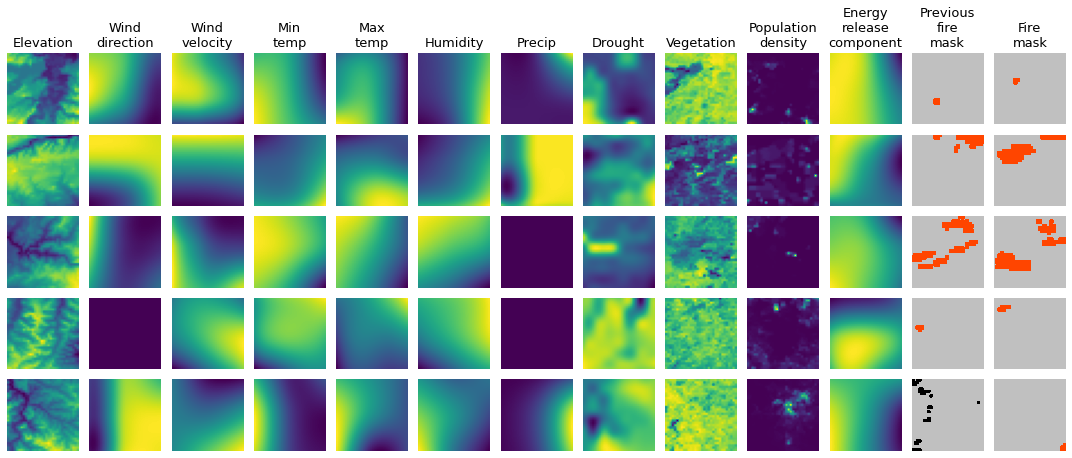

In [11]:
fig = plt.figure(figsize=(15,6.5))

for i in range(n_rows):
  for j in range(n_features + 1):
    plt.subplot(n_rows, n_features + 1, i * (n_features + 1) + j + 1)
    if i == 0:
      plt.title(TITLES[j], fontsize=13)
    if j < n_features - 1:
      plt.imshow(inputs[i, :, :, j], cmap='viridis')
    if j == n_features - 1:
      plt.imshow(inputs[i, :, :, -1], cmap=CMAP, norm=NORM)
    if j == n_features:
      plt.imshow(labels[i, :, :, 0], cmap=CMAP, norm=NORM) 
    plt.axis('off')
plt.tight_layout()

**First Model**

**DHD** We tested there several architectures that originated from the original paper. On every architecture we chose, results were disapointing, even on the training set. Our hypothesis is that averaging wind, humidity and precipitation over a day is very innacurate. These tests were the basis of our decision to change the dataset to get a better time resolution.

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 32, 32, 12)] 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 32, 32, 16)   1744        input_1[0][0]                    
__________________________________________________________________________________________________
activation (Activation)         (None, 32, 32, 16)   0           conv2d[0][0]                     
__________________________________________________________________________________________________
dropout (Dropout)               (None, 32, 32, 16)   0           activation[0][0]                 
______________________________________________________________________________________________

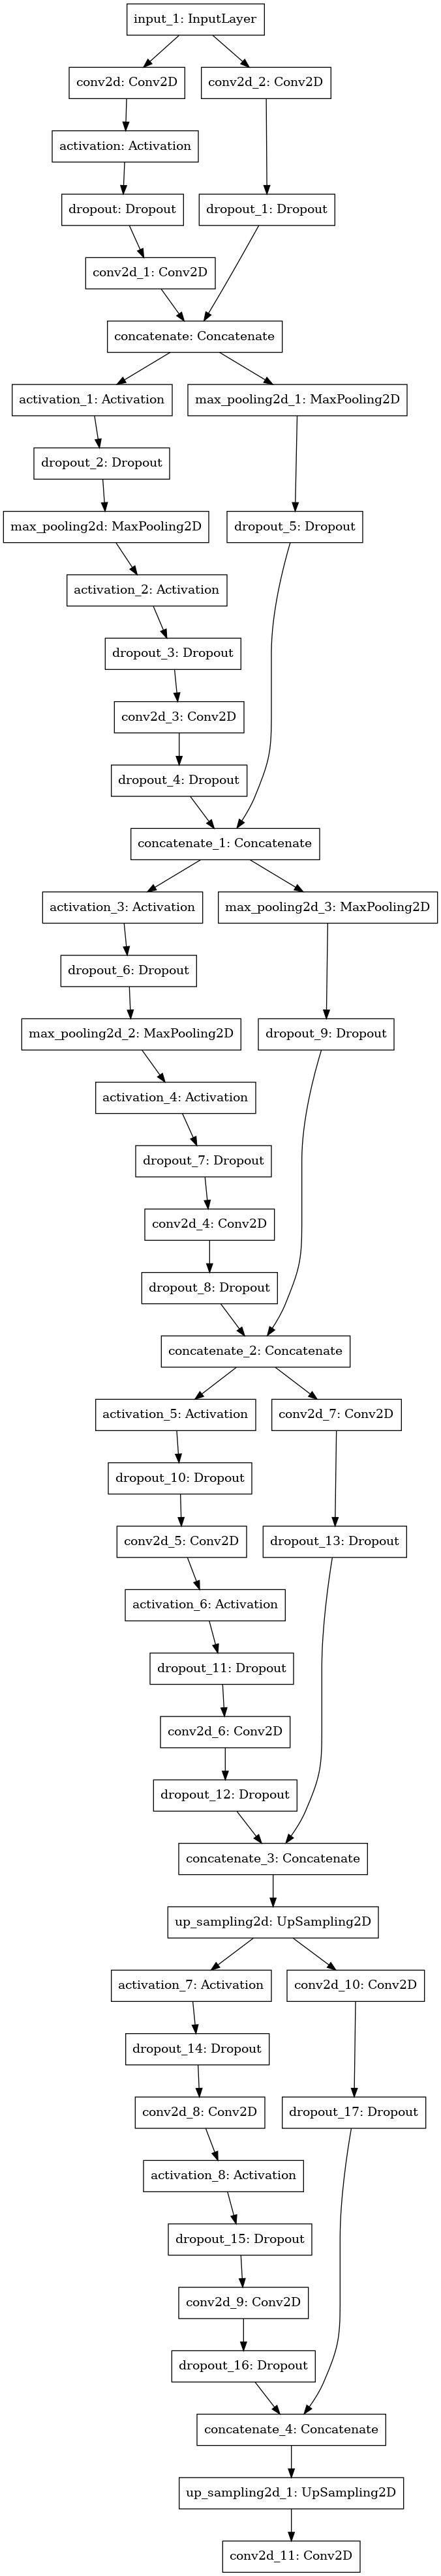

In [12]:
from tensorflow import keras
from tensorflow.keras import layers
'''
block_Conv=[
    layers.Activation('leaky_relu'),
    layers.Dropout(0.1),
    layers.Conv2D(filters=16,kernel_size=3,padding='same'),
    layers.Activation('leaky_relu'),
    layers.Dropout(0.1),
    layers.Conv2D(filters=16,kernel_size=3,padding='same'),
    layers.Dropout(0.1)]
block_Max=[
    layers.Activation('leaky_relu'),
    layers.Dropout(0.1),
    layers.MaxPool2D(),
    layers.Activation('leaky_relu'),
    layers.Dropout(0.1),
    layers.Conv2D(filters=16,kernel_size=3,padding='same'),
    layers.Dropout(0.1)]
'''
def Block_Conv(x0):
    b10 = layers.Activation('leaky_relu')(x0)
    b11 = layers.Dropout(0.1)(b10)
    b12 = layers.Conv2D(filters=16,kernel_size=3,padding='same')(b11)
    b13 = layers.Activation('leaky_relu')(b12)
    b14 = layers.Dropout(0.1)(b13)
    b15 = layers.Conv2D(filters=16,kernel_size=3,padding='same')(b14)
    b16 = layers.Dropout(0.1)(b15)
    
    b20 = layers.Conv2D(filters=16,kernel_size=3,padding='same')(x0)
    b21 = layers.Dropout(0.1)(b20)
    
    return layers.Concatenate()([b16,b21])

def Block_Max(x0):
    b10 = layers.Activation('leaky_relu')(x0)
    b11 = layers.Dropout(0.1)(b10)
    b12 = layers.MaxPool2D(padding = 'same')(b11)
    b13 = layers.Activation('leaky_relu')(b12)
    b14 = layers.Dropout(0.1)(b13)
    b15 = layers.Conv2D(filters=16,kernel_size=3,padding='same')(b14)
    b16 = layers.Dropout(0.1)(b15)
    
    b20 = layers.MaxPool2D(padding='same')(x0)
    b21 = layers.Dropout(0.1)(b20)
    return layers.Concatenate()([b16,b21])

In = keras.Input(shape = (32,32,12))
x1 = layers.Conv2D(filters=16,kernel_size=3,padding='same',input_shape=(32,32,12))(In)
x2 = layers.Activation('leaky_relu')(x1)
x3 = layers.Dropout(0.1)(x2)
x4 = layers.Conv2D(filters=16,kernel_size=3,padding='same')(x3)

y1 = layers.Conv2D(filters=16,kernel_size=3,padding='same',input_shape=(32,32,12))(In)
y2 = layers.Dropout(0.1)(y1)

w1 = layers.Concatenate()([x4, y2])

w2 = Block_Max(w1)

w3= Block_Max(w2)


w4 = Block_Conv(w3)

w45 = layers.UpSampling2D()(w4)

w5 = Block_Conv(w45)

w5o= layers.UpSampling2D()(w5)

outputs = layers.Conv2D(filters=1,kernel_size=3,padding='same',activation='sigmoid')(w5o)

model = keras.Model(inputs=In
                    , outputs=outputs)

'''

model=keras.Sequential([
    layers.Conv2D(filters=16,kernel_size=3,padding='same',input_shape=(32,32,12)),
    layers.Activation('leaky_relu'),
    layers.Dropout(0.1),
    layers.Conv2D(filters=16,kernel_size=3,padding='same')
]+block_Max+block_Max+[layers.UpSampling2D()]
    +block_Conv+[layers.UpSampling2D()]+block_Conv+
    [layers.Conv2D(filters=1,kernel_size=3,padding='same',activation='sigmoid')])
    '''
model.summary()

def loss_fn(y_true,y_pred):
    res=tf.keras.losses.BinaryCrossentropy()
    return tf.reduce_mean(res, axis=-1)

def weighted_bce(y_true, y_pred):
    weights = (y_true * 40.) +1.
    bce = keras.backend.binary_crossentropy(y_true, y_pred)
    weighted_bce = keras.backend.mean(bce * weights)
    return weighted_bce
opt=tf.keras.optimizers.Adam(epsilon=0.05,clipvalue=0.1) ##Goal is is not to have fast convergence but precise...
##Test are to be made with other loss functions.
model.compile(
optimizer=opt,
loss= weighted_bce
)
keras.utils.plot_model(model)

#model.fit(dataset, epochs=150,verbose='auto')

In [13]:
class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []

    def on_batch_end(self, batch, logs={}):
        self.losses.append(logs.get('loss'))

In [14]:
history = LossHistory()
model.fit(dataset, epochs=200,verbose='auto',callbacks=[history])

###Alternatively 
##hdf5_file="../input/aspenoak-nextday-prediction-v0-0-c26a4d/model_StrideNone_32filters.h5"

#model.load_weights(hdf5_file)

Epoch 1/200


2022-11-07 18:06:04.193696: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


150/150 [==============================] - 39s 187ms/step - loss: 249.9647
Epoch 2/200
150/150 [==============================] - 7s 46ms/step - loss: 15.0436
Epoch 3/200
150/150 [==============================] - 7s 47ms/step - loss: 2.9526
Epoch 4/200
150/150 [==============================] - 7s 44ms/step - loss: 1.6473
Epoch 5/200
150/150 [==============================] - 6s 43ms/step - loss: 1.4340
Epoch 6/200
150/150 [==============================] - 7s 46ms/step - loss: 1.3550
Epoch 7/200
150/150 [==============================] - 7s 50ms/step - loss: 1.3343
Epoch 8/200
150/150 [==============================] - 7s 45ms/step - loss: 1.3111
Epoch 9/200
150/150 [==============================] - 7s 46ms/step - loss: 1.3012
Epoch 10/200
150/150 [==============================] - 7s 49ms/step - loss: 1.2793
Epoch 11/200
150/150 [==============================] - 6s 42ms/step - loss: 1.2703
Epoch 12/200
150/150 [==============================] - 7s 44ms/step - loss: 1.2864
Epoch 13

In [15]:
# history = LossHistory()
#model.fit(dataset, epochs=200,verbose='auto',callbacks=[history])

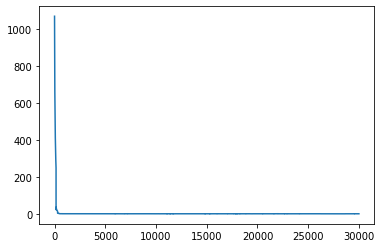

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.losses)
plt.show()
plt.close()

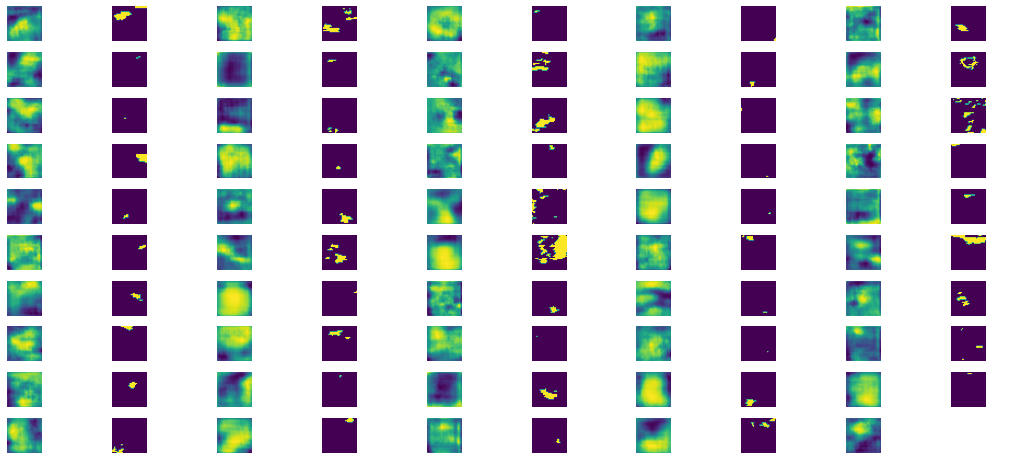

In [17]:
res=model.predict(inputs[:100,:,:,:])

    
    
fig = plt.figure(figsize=(15,6.5))

for i in range(10):
  for j in range(5):
    plt.imshow(labels[5*i+j])
    plt.subplot(10,10,1+10*i+2*j)
    plt.axis('off')
    plt.imshow(res[5*i+j])
    plt.subplot(10,10,1+10*i+2*j+1)
    plt.axis('off')
plt.tight_layout()


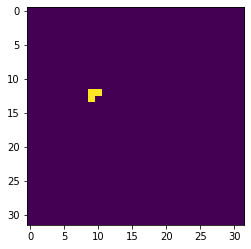

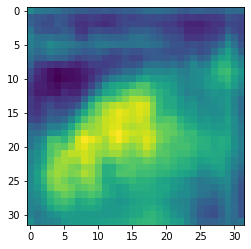

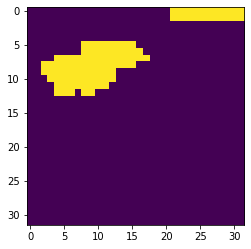

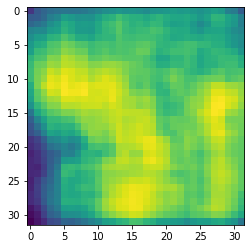

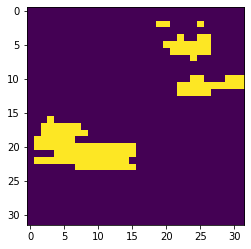

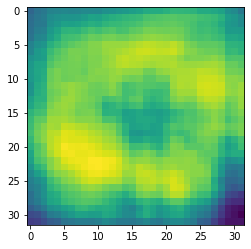

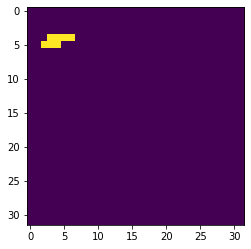

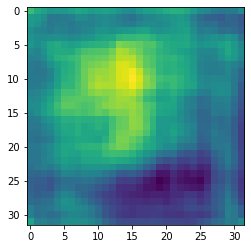

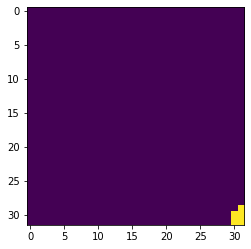

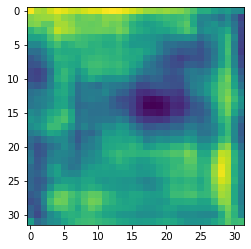

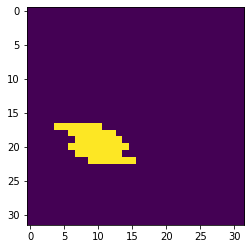

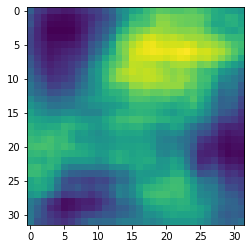

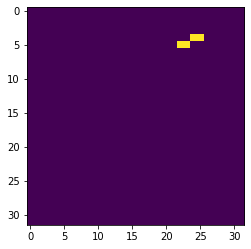

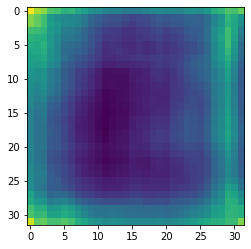

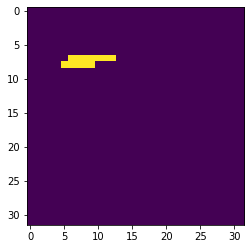

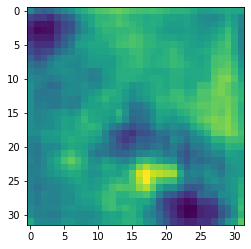

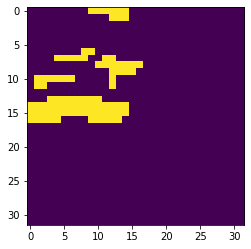

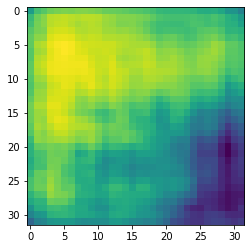

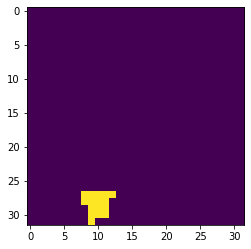

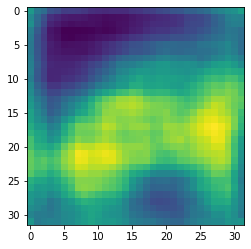

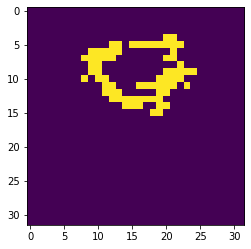

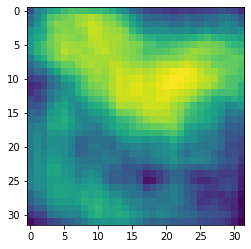

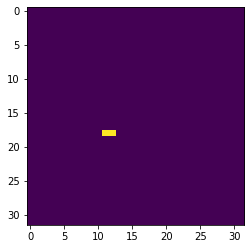

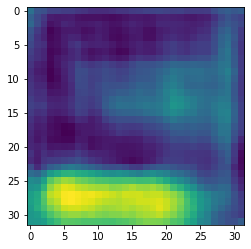

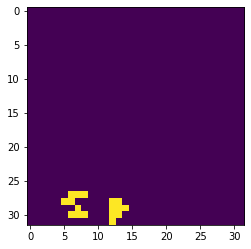

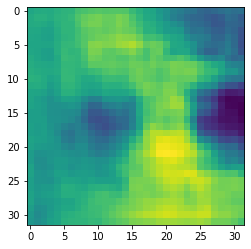

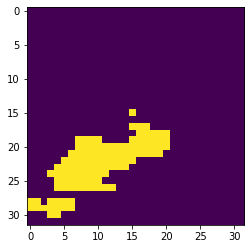

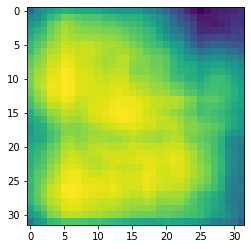

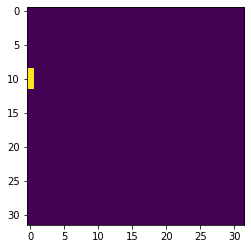

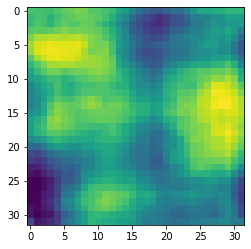

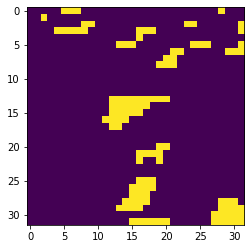

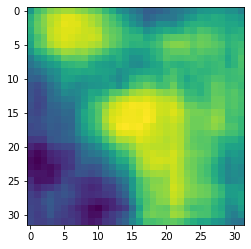

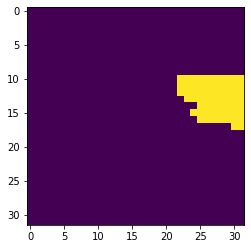

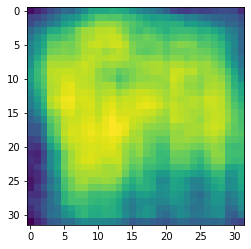

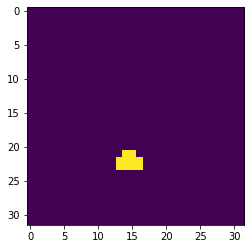

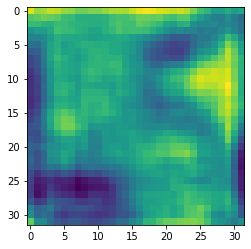

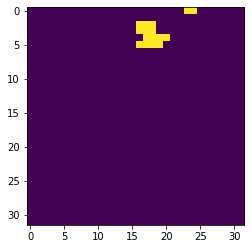

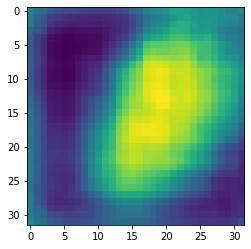

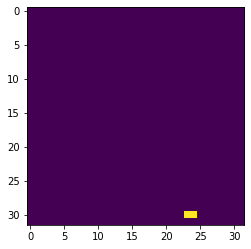

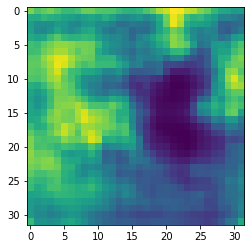

In [18]:
res=model.predict(inputs[:100,:,:,:])

for i in range(20):
    plt.imshow(labels[i])
    plt.show()
    plt.imshow(res[i])
    plt.show()

In [19]:
model.save_weights("model_StrideNone_32filters.h5")